## SECTION 1: GPU VERIFICATION

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch

print("="*50)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name       :", torch.cuda.get_device_name(0))
    print("Capability     :", torch.cuda.get_device_capability(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device         :", DEVICE)
print("="*50)

CUDA Available : True
GPU Name       : NVIDIA GeForce RTX 5080
Capability     : (12, 0)
Device         : cuda


## SECTION 2: LIBRARY IMPORTS

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

import albumentations as A
import timm

In [3]:
torch.set_float32_matmul_precision("high")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("Fast GPU matmul settings enabled")

Fast GPU matmul settings enabled


## SECTION 3: PATH CONFIGURATION

In [ ]:
from pathlib import Path

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / 'data').exists():
    ROOT_DIR = ROOT_DIR.parent

BASE_DIR = str(ROOT_DIR)

DATA_DIR = os.path.join(
    BASE_DIR,
    r"data\raw\brats2020\BraTS2020_training_data\content\data"
)

META_PATH = os.path.join(DATA_DIR, 'meta_data.csv')

SAVE_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(SAVE_DIR, exist_ok=True)

print('BASE_DIR :', BASE_DIR)
print('DATA_DIR :', DATA_DIR)
print('META_PATH:', META_PATH)
print('SAVE_DIR :', SAVE_DIR)
print('META exists:', os.path.exists(META_PATH))


## SECTION 4: LOAD METADATA

In [5]:
meta = pd.read_csv(META_PATH)

print("Total slices :", len(meta))
print("Tumor slices :", (meta['target']==1).sum())
print("Normal slices:", (meta['target']==0).sum())
print("Volumes      :", meta['volume'].nunique())

meta.head()

Total slices : 57195
Tumor slices : 24422
Normal slices: 32773
Volumes      : 369


,slice_path,target,volume,slice
0,/content/data/volume_41_slice_0.h5,0,41,0
1,/content/data/volume_41_slice_1.h5,0,41,1
2,/content/data/volume_41_slice_2.h5,0,41,2
3,/content/data/volume_41_slice_3.h5,0,41,3
4,/content/data/volume_41_slice_4.h5,0,41,4


## SECTION 5: UTILITIES & DATASET

In [ ]:
def normalize_channel(channel):
    mn = channel.min()
    mx = channel.max()
    if mx > mn:
        return (channel - mn) / (mx - mn)
    return channel


class BraTSDataset(Dataset):

    def __init__(self, meta_df, data_dir, mode='classify', augment=False):
        self.data_dir = data_dir
        self.mode = mode
        self.augment = augment

        if mode == 'segment':
            self.df = meta_df[meta_df['target'] == 1].reset_index(drop=True)
        else:
            self.df = meta_df.reset_index(drop=True)

        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.1,
                rotate_limit=15,
                p=0.4
            ),
            A.GaussNoise(p=0.2)
        ]) if augment else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        fname = f"volume_{int(row['volume'])}_slice_{int(row['slice'])}.h5"
        fpath = os.path.join(self.data_dir, fname)

        with h5py.File(fpath, 'r') as f:
            image = f['image'][()].astype(np.float32)
            mask  = f['mask'][()].astype(np.float32)

        for c in range(4):
            image[:, :, c] = normalize_channel(image[:, :, c])

        if self.aug:
            augmented = self.aug(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask  = torch.tensor(mask).permute(2, 0, 1).float()

        if self.mode == 'classify':
            label = torch.tensor(int(row['target']), dtype=torch.long)
            return image, label

        return image, mask

## SECTION 6: DATASET SANITY CHECK

In [7]:
cls_ds = BraTSDataset(meta, DATA_DIR, mode='classify', augment=False)

img, lbl = cls_ds[0]

print("Classification Dataset Size :", len(cls_ds))
print("Image Shape                 :", img.shape)
print("Label                       :", lbl)


seg_ds = BraTSDataset(meta, DATA_DIR, mode='segment', augment=False)

img_s, msk_s = seg_ds[0]

print("\nSegmentation Dataset Size   :", len(seg_ds))
print("Image Shape                 :", img_s.shape)
print("Mask Shape                  :", msk_s.shape)

Classification Dataset Size : 57195
Image Shape                 : torch.Size([4, 240, 240])
Label                       : tensor(0)

Segmentation Dataset Size   : 24422
Image Shape                 : torch.Size([4, 240, 240])
Mask Shape                  : torch.Size([3, 240, 240])


## SECTION 7: SPLIT DATA & DATALOADERS

In [8]:
from torch.utils.data import random_split

cls_dataset = BraTSDataset(
    meta,
    DATA_DIR,
    mode='classify',
    augment=False
)

cls_train_size = int(0.8 * len(cls_dataset))
cls_val_size   = len(cls_dataset) - cls_train_size

cls_train, cls_val = random_split(
    cls_dataset,
    [cls_train_size, cls_val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Classification Train :", len(cls_train))
print("Classification Val   :", len(cls_val))

seg_dataset = BraTSDataset(
    meta,
    DATA_DIR,
    mode='segment',
    augment=False
)

seg_train_size = int(0.8 * len(seg_dataset))
seg_val_size   = len(seg_dataset) - seg_train_size

seg_train, seg_val = random_split(
    seg_dataset,
    [seg_train_size, seg_val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Segmentation Train :", len(seg_train))
print("Segmentation Val   :", len(seg_val))

cls_train_loader = DataLoader(
    cls_train,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

cls_val_loader = DataLoader(
    cls_val,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

seg_train_loader = DataLoader(
    seg_train,
    batch_size=48,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

seg_val_loader = DataLoader(
    seg_val,
    batch_size=48,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

for imgs, lbls in cls_train_loader:
    print("Classification batch images :", imgs.shape)
    print("Classification batch labels :", lbls.shape)
    break

for imgs, msks in seg_train_loader:
    print("Segmentation batch images   :", imgs.shape)
    print("Segmentation batch masks    :", msks.shape)
    break

Classification Train : 45756
Classification Val   : 11439
Segmentation Train : 19537
Segmentation Val   : 4885
Classification batch images : torch.Size([32, 4, 240, 240])
Classification batch labels : torch.Size([32])
Segmentation batch images   : torch.Size([48, 4, 240, 240])
Segmentation batch masks    : torch.Size([48, 3, 240, 240])


## SECTION 8: CLASSIFIER MODEL (EfficientNet-B4)

In [9]:
import timm
import torch.nn as nn

class TumorClassifier(nn.Module):
    """
    EfficientNet-B4
    4-channel MRI input
    2 output classes
    """

    def __init__(self, num_classes=2, in_channels=4, pretrained=True):
        super().__init__()

        self.model = timm.create_model(
            'efficientnet_b4',
            pretrained=pretrained,
            num_classes=num_classes
        )

        old_conv = self.model.conv_stem

        self.model.conv_stem = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():
            self.model.conv_stem.weight[:, :3] = old_conv.weight
            self.model.conv_stem.weight[:, 3] = old_conv.weight.mean(dim=1)

    def forward(self, x):
        return self.model(x)
        
cls_model = TumorClassifier(
    num_classes=2,
    in_channels=4,
    pretrained=True
).to(DEVICE)

print("Classifier loaded on:", DEVICE)
with torch.no_grad():
    dummy = torch.randn(2, 4, 240, 240).to(DEVICE)
    out = cls_model(dummy)

print("Output shape :", out.shape)
total_params = sum(
    p.numel() for p in cls_model.parameters()
    if p.requires_grad
)

print(f"Trainable params : {total_params:,}")

Classifier loaded on: cuda
Output shape : torch.Size([2, 2])
Trainable params : 17,552,634


## SECTION 9: UNET MODEL

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)
class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=3, features=[32,64,128,256]):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        ch = in_channels
        for feature in features:
            self.downs.append(DoubleConv(ch, feature))
            ch = feature

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature*2,
                    feature,
                    kernel_size=2,
                    stride=2
                )
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)

            skip = skip_connections[idx//2]

            if x.shape != skip.shape:
                x = nn.functional.interpolate(
                    x,
                    size=skip.shape[2:]
                )

            concat = torch.cat((skip, x), dim=1)
            x = self.ups[idx+1](concat)

        return self.final(x)
        
seg_model = UNet(
    in_channels=4,
    out_channels=3
).to(DEVICE)

print("Segmentation model loaded on:", DEVICE)
with torch.no_grad():
    dummy = torch.randn(2, 4, 240, 240).to(DEVICE)
    out = seg_model(dummy)

print("Output shape :", out.shape)
total_params = sum(
    p.numel() for p in seg_model.parameters()
    if p.requires_grad
)

print(f"Trainable params : {total_params:,}")

Segmentation model loaded on: cuda
Output shape : torch.Size([2, 3, 240, 240])
Trainable params : 7,763,395


## SECTION 10: METRICS & LOSSES

In [11]:
def dice_coefficient(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = (2*inter + smooth)/(union + smooth)

    return dice.mean()
def iou_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) - inter

    iou = (inter + smooth)/(union + smooth)

    return iou.mean()
def pixel_accuracy(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    correct = (pred == target).float().sum()
    total = torch.numel(pred)

    return correct / total
cls_criterion = nn.CrossEntropyLoss()

print("Classification loss ready")

Classification loss ready


## SECTION 11: SEGMENTATION LOSS (Dice + BCE)

In [12]:
class DiceBCELoss(nn.Module):
    def __init__(self, weight_dice=0.7, weight_bce=0.3):
        super().__init__()

        self.wd = weight_dice
        self.wb = weight_bce

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):

        bce = self.bce(pred, target)

        pred_sig = torch.sigmoid(pred)

        inter = (pred_sig * target).sum(dim=(2,3))
        union = pred_sig.sum(dim=(2,3)) + target.sum(dim=(2,3))

        dice = 1 - ((2*inter + 1e-6)/(union + 1e-6))
        dice = dice.mean()

        total_loss = self.wd*dice + self.wb*bce

        return total_loss
seg_criterion = DiceBCELoss()

print("Segmentation loss ready")
with torch.no_grad():
    dummy_pred = torch.randn(2,3,240,240).to(DEVICE)
    dummy_target = torch.rand(2,3,240,240).to(DEVICE)

    loss = seg_criterion(dummy_pred, dummy_target)

print("Test segmentation loss :", loss.item())

Segmentation loss ready
Test segmentation loss : 0.5926979780197144


## SECTION 12: TRAIN CLASSIFIER 

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.amp import autocast, GradScaler

def train_classifier(model, train_loader, val_loader, epochs=10, lr=1e-4):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = GradScaler()

    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):

        model.train()

        train_loss = 0
        train_preds = []
        train_labels = []

        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]"):

            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda'):
                out = model(imgs)
                loss = cls_criterion(out, lbls)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            preds = out.argmax(1)

            train_preds.extend(preds.detach().cpu().numpy())
            train_labels.extend(lbls.detach().cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_prec = precision_score(train_labels, train_preds)
        train_rec = recall_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds)

        model.eval()

        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():

            for imgs, lbls in val_loader:

                imgs = imgs.to(DEVICE, non_blocking=True)
                lbls = lbls.to(DEVICE, non_blocking=True)

                out = model(imgs)
                loss = cls_criterion(out, lbls)

                val_loss += loss.item()

                preds = out.argmax(1)

                val_preds.extend(preds.detach().cpu().numpy())
                val_labels.extend(lbls.detach().cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_prec = precision_score(val_labels, val_preds)
        val_rec = recall_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds)

        scheduler.step()

        print(f"\nEpoch {epoch:02d}")
        print(f"Train Loss : {train_loss/len(train_loader):.4f}")
        print(f"Train Acc  : {train_acc:.4f}")
        print(f"Train Prec : {train_prec:.4f}")
        print(f"Train Rec  : {train_rec:.4f}")
        print(f"Train F1   : {train_f1:.4f}")

        print(f"Val Loss   : {val_loss/len(val_loader):.4f}")
        print(f"Val Acc    : {val_acc:.4f}")
        print(f"Val Prec   : {val_prec:.4f}")
        print(f"Val Rec    : {val_rec:.4f}")
        print(f"Val F1     : {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            torch.save(
                model.state_dict(),
                os.path.join(SAVE_DIR, "best_classifier.pth")
            )

            print("Best classifier saved")

    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

    return model

cls_model = train_classifier(
    cls_model,
    cls_train_loader,
    cls_val_loader,
    epochs=10,
    lr=1e-4
)

Epoch 1/10 [Train]: 100%|██████████████████████████████████████████████████████████| 1430/1430 [08:15<00:00,  2.89it/s]



Epoch 01
Train Loss : 0.2624
Train Acc  : 0.8878
Train Prec : 0.8806
Train Rec  : 0.8522
Train F1   : 0.8661
Val Loss   : 0.3085
Val Acc    : 0.9329
Val Prec   : 0.9648
Val Rec    : 0.8767
Val F1     : 0.9186
Best classifier saved


Epoch 2/10 [Train]: 100%|██████████████████████████████████████████████████████████| 1430/1430 [05:41<00:00,  4.19it/s]



Epoch 02
Train Loss : 0.1199
Train Acc  : 0.9527
Train Prec : 0.9620
Train Rec  : 0.9255
Train F1   : 0.9434
Val Loss   : 0.1849
Val Acc    : 0.9565
Val Prec   : 0.9703
Val Rec    : 0.9275
Val F1     : 0.9484
Best classifier saved


Epoch 3/10 [Train]: 100%|██████████████████████████████████████████████████████████| 1430/1430 [05:40<00:00,  4.20it/s]


...


Epoch 08
Train Loss : 0.0031
Train Acc  : 0.9990
Train Prec : 0.9992
Train Rec  : 0.9985
Train F1   : 0.9988
Val Loss   : 0.3225
Val Acc    : 0.9707
Val Prec   : 0.9774
Val Rec    : 0.9542
Val F1     : 0.9657


Epoch 9/10 [Train]: 100%|██████████████████████████████████████████████████████████| 1430/1430 [08:12<00:00,  2.90it/s]



Epoch 09
Train Loss : 0.0019
Train Acc  : 0.9994
Train Prec : 0.9994
Train Rec  : 0.9992
Train F1   : 0.9993
Val Loss   : 0.7166
Val Acc    : 0.9712
Val Prec   : 0.9824
Val Rec    : 0.9504
Val F1     : 0.9661


Epoch 10/10 [Train]: 100%|█████████████████████████████████████████████████████████| 1430/1430 [05:53<00:00,  4.04it/s]



Epoch 10
Train Loss : 0.0017
Train Acc  : 0.9996
Train Prec : 0.9996
Train Rec  : 0.9995
Train F1   : 0.9995
Val Loss   : 0.1825
Val Acc    : 0.9730
Val Prec   : 0.9771
Val Rec    : 0.9599
Val F1     : 0.9684
Best classifier saved

Best Validation Accuracy: 0.9730


## SECTION 13: RESIDUAL ATTENTION UNET ARCHITECTURE

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False)

    def forward(self, x):

        identity = self.skip(x)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x += identity

        return F.relu(x)

class AttentionBlock(nn.Module):
    def __init__(self, g_ch, x_ch, int_ch):
        super().__init__()

        self.Wg = nn.Sequential(
            nn.Conv2d(g_ch, int_ch, 1),
            nn.BatchNorm2d(int_ch)
        )

        self.Wx = nn.Sequential(
            nn.Conv2d(x_ch, int_ch, 1),
            nn.BatchNorm2d(int_ch)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(int_ch, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, g, x):

        g1 = self.Wg(g)
        x1 = self.Wx(x)

        psi = F.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

class ResidualAttentionUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=3):
        super().__init__()

        self.pool = nn.MaxPool2d(2,2)

        self.enc1 = ResidualBlock(in_channels, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)
        self.enc4 = ResidualBlock(256, 512)

        self.bottleneck = ResidualBlock(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.att4 = AttentionBlock(512, 512, 256)
        self.dec4 = ResidualBlock(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.att3 = AttentionBlock(256, 256, 128)
        self.dec3 = ResidualBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.att2 = AttentionBlock(128, 128, 64)
        self.dec2 = ResidualBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.att1 = AttentionBlock(64, 64, 32)
        self.dec1 = ResidualBlock(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

## SECTION 14: IMPROVED SEGMENTATION LOSS

In [15]:
class ImprovedDiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):

        bce = self.bce(pred, target)

        pred_sig = torch.sigmoid(pred)

        inter = (pred_sig * target).sum(dim=(2,3))
        union = pred_sig.sum(dim=(2,3)) + target.sum(dim=(2,3))

        dice = 1 - ((2*inter + 1e-6)/(union + 1e-6))
        dice = dice.mean()

        focal = ((1 - pred_sig) ** 2 * target).mean()

        return 0.5*dice + 0.3*bce + 0.2*focal

## SECTION 15: SEGMENTATION MODEL INITIALIZATION

In [16]:
seg_model = ResidualAttentionUNet(
    in_channels=4,
    out_channels=3
).to(DEVICE)

seg_criterion = ImprovedDiceBCELoss()

print(" Segmentation model ready")

 Segmentation model ready


## SECTION 16: TRAIN SEGMENTATION

In [17]:
import os
import torch
import torch.optim as optim
from tqdm import tqdm
from torch.amp import autocast, GradScaler


@torch.no_grad()
def compute_metrics(pred, target, smooth=1e-6):
    prob = torch.sigmoid(pred)
    bin_pred = prob > 0.5
    tgt_bool = target.bool()

    inter = (bin_pred & tgt_bool).float().sum(dim=(2, 3))
    pred_sum = bin_pred.float().sum(dim=(2, 3))
    tgt_sum = target.sum(dim=(2, 3))

    dice = ((2 * inter + smooth) / (pred_sum + tgt_sum + smooth)).mean().item()
    iou = ((inter + smooth) / (pred_sum + tgt_sum - inter + smooth)).mean().item()
    pix = (bin_pred == tgt_bool).float().mean().item()

    return dice, iou, pix


def train_segmentation(model, train_loader, val_loader, epochs=15, lr=1e-4):

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = GradScaler()

    torch.backends.cudnn.benchmark = True

    best_dice = 0.0

    for epoch in range(1, epochs + 1):

        model.train()

        train_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs} [Train]",
            leave=False
        )

        for imgs, msks in train_bar:

            imgs = imgs.to(DEVICE, non_blocking=True)
            msks = msks.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda'):
                preds = model(imgs)
                loss = seg_criterion(preds, msks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        model.eval()

        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0
        val_pix = 0.0

        with torch.no_grad():

            for imgs, msks in val_loader:

                imgs = imgs.to(DEVICE, non_blocking=True)
                msks = msks.to(DEVICE, non_blocking=True)

                with autocast(device_type='cuda'):
                    preds = model(imgs)
                    loss = seg_criterion(preds, msks)

                val_loss += loss.item()

                dice, iou, pix = compute_metrics(preds, msks)
                val_dice += dice
                val_iou += iou
                val_pix += pix

        scheduler.step()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)
        avg_val_pix = val_pix / len(val_loader)

        print(f"\nEpoch {epoch:02d}/{epochs}")
        print(f"Train Loss : {avg_train_loss:.4f}")
        print(f"Val Loss   : {avg_val_loss:.4f}")
        print(f"Val Dice   : {avg_val_dice:.4f}")
        print(f"Val IoU    : {avg_val_iou:.4f}")
        print(f"Val Pix    : {avg_val_pix:.4f}")
        print(f"LR         : {scheduler.get_last_lr()[0]:.8f}")

        if avg_val_dice > best_dice:
            best_dice = avg_val_dice

            torch.save(
                model.state_dict(),
                os.path.join(SAVE_DIR, "best_unet.pth")
            )

            print("Best segmentation model saved")

    print(f"\nBest Validation Dice: {best_dice:.4f}")

    return model

seg_model = train_segmentation(
    seg_model,
    seg_train_loader,
    seg_val_loader,
    epochs=12,
    lr=1e-4
)


Epoch 01/12
Train Loss : 0.3560
Val Loss   : 0.3177
Val Dice   : 0.5864
Val IoU    : 0.5025
Val Pix    : 0.9942
LR         : 0.00009830
Best segmentation model saved



Epoch 02/12
Train Loss : 0.2675
Val Loss   : 0.2694
Val Dice   : 0.6464
Val IoU    : 0.5673
Val Pix    : 0.9958
LR         : 0.00009330
Best segmentation model saved



Epoch 03/12
Train Loss : 0.2554
Val Loss   : 0.2613
Val Dice   : 0.6820
Val IoU    : 0.6047
Val Pix    : 0.9964
LR         : 0.00008536
Best segmentation model saved



Epoch 04/12
Train Loss : 0.2471
Val Loss   : 0.2533
Val Dice   : 0.6036
Val IoU    : 0.5224
Val Pix    : 0.9962
LR         : 0.00007500



Epoch 05/12
Train Loss : 0.2399
Val Loss   : 0.2406
Val Dice   : 0.6660
Val IoU    : 0.5885
Val Pix    : 0.9967
LR         : 0.00006294


...


Epoch 08/12
Train Loss : 0.2223
Val Loss   : 0.2217
Val Dice   : 0.7365
Val IoU    : 0.6651
Val Pix    : 0.9977
LR         : 0.00002500
Best segmentation model saved



Epoch 09/12
Train Loss : 0.2160
Val Loss   : 0.2228
Val Dice   : 0.7637
Val IoU    : 0.6917
Val Pix    : 0.9978
LR         : 0.00001464
Best segmentation model saved



Epoch 10/12
Train Loss : 0.2120
Val Loss   : 0.2149
Val Dice   : 0.7744
Val IoU    : 0.7059
Val Pix    : 0.9981
LR         : 0.00000670
Best segmentation model saved



Epoch 11/12
Train Loss : 0.2091
Val Loss   : 0.2136
Val Dice   : 0.7706
Val IoU    : 0.7025
Val Pix    : 0.9981
LR         : 0.00000170



Epoch 12/12
Train Loss : 0.2073
Val Loss   : 0.2128
Val Dice   : 0.7791
Val IoU    : 0.7116
Val Pix    : 0.9981
LR         : 0.00000000
Best segmentation model saved

Best Validation Dice: 0.7791


## SECTION 17: FURTHER SEGMENTATION FINETUNING

In [18]:
seg_model = train_segmentation(
    seg_model,
    seg_train_loader,
    seg_val_loader,
    epochs=5,
    lr=3e-5
)


Epoch 01/5
Train Loss : 0.2112
Val Loss   : 0.2174
Val Dice   : 0.7728
Val IoU    : 0.7034
Val Pix    : 0.9980
LR         : 0.00002714
Best segmentation model saved



Epoch 02/5
Train Loss : 0.2100
Val Loss   : 0.2133
Val Dice   : 0.7846
Val IoU    : 0.7169
Val Pix    : 0.9981
LR         : 0.00001964
Best segmentation model saved



Epoch 03/5
Train Loss : 0.2076
Val Loss   : 0.2127
Val Dice   : 0.7852
Val IoU    : 0.7178
Val Pix    : 0.9981
LR         : 0.00001036
Best segmentation model saved



Epoch 04/5
Train Loss : 0.2048
Val Loss   : 0.2095
Val Dice   : 0.7829
Val IoU    : 0.7165
Val Pix    : 0.9982
LR         : 0.00000286



Epoch 05/5
Train Loss : 0.2023
Val Loss   : 0.2088
Val Dice   : 0.7961
Val IoU    : 0.7303
Val Pix    : 0.9982
LR         : 0.00000000
Best segmentation model saved

Best Validation Dice: 0.7961


## SECTION 18: LOAD BEST MODELS

In [19]:
cls_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_classifier.pth"),
        map_location=DEVICE
    )
)

cls_model.eval()

print(" Best classifier loaded")

 Best classifier loaded


In [20]:
seg_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_unet.pth"),
        map_location=DEVICE
    )
)

seg_model.eval()

print(" Best segmentation model loaded")

 Best segmentation model loaded


## SECTION 19: REGION-WISE SEGMENTATION METRIC

In [21]:
def region_dice(pred_mask, true_mask, smooth=1e-6):
    """
    Computes Dice score for each tumor region channel:
    channel 0 -> NCR
    channel 1 -> Edema
    channel 2 -> ET
    """

    scores = []

    for c in range(pred_mask.shape[0]):
        pred_bin = (pred_mask[c] > 0.5).astype(np.float32)
        true_bin = true_mask[:, :, c].astype(np.float32)

        inter = (pred_bin * true_bin).sum()
        union = pred_bin.sum() + true_bin.sum()

        dice = (2 * inter + smooth) / (union + smooth)
        scores.append(dice)

    return scores

## SECTION 20: RANDOM INFERENCE AND VISUALIZATION

In [22]:
def run_random_inference(cls_model, seg_model, meta, data_dir, n_samples=5):

    cls_model.eval()
    seg_model.eval()

    tumor_samples = meta[meta['target'] == 1].sample(n_samples)

    print(f"Running RANDOM inference on {n_samples} tumor samples...\n")

    for idx, (_, row) in enumerate(tumor_samples.iterrows(), 1):

        fname = f"volume_{int(row['volume'])}_slice_{int(row['slice'])}.h5"
        fpath = os.path.join(data_dir, fname)

        with h5py.File(fpath, 'r') as f:
            image = f['image'][()].astype(np.float32)
            mask = f['mask'][()].astype(np.float32)

        # ================= Normalize =================
        img_norm = image.copy()

        for c in range(4):
            mn = img_norm[:, :, c].min()
            mx = img_norm[:, :, c].max()

            if mx > mn:
                img_norm[:, :, c] = (img_norm[:, :, c] - mn) / (mx - mn)

        tensor = (
            torch.tensor(img_norm)
            .permute(2,0,1)
            .unsqueeze(0)
            .float()
            .to(DEVICE)
        )

        # ================= Inference =================
        with torch.no_grad():

            cls_out = cls_model(tensor)
            pred_cls = cls_out.argmax(1).item()

            seg_out = seg_model(tensor)
            seg_out = torch.sigmoid(seg_out).squeeze(0).cpu().numpy()

        # ================= Region Dice =================
        scores = region_dice(seg_out, mask)

        print(f"Sample {idx}")
        print(f"Volume {int(row['volume'])} Slice {int(row['slice'])}")
        print(f"Prediction : {'TUMOR' if pred_cls==1 else 'NO TUMOR'}")
        print(f"NCR Dice   : {scores[0]:.4f}")
        print(f"Edema Dice : {scores[1]:.4f}")
        print(f"ET Dice    : {scores[2]:.4f}\n")

        # ================= Plot =================
        fig, axes = plt.subplots(1,4, figsize=(20,5))

        axes[0].imshow(img_norm[:,:,3], cmap='gray')
        axes[0].set_title("FLAIR")
        axes[0].axis('off')

        gt_overlay = np.zeros((240,240,3))
        gt_overlay[:,:,0] = mask[:,:,2]
        gt_overlay[:,:,1] = mask[:,:,1]
        gt_overlay[:,:,2] = mask[:,:,0]

        axes[1].imshow(img_norm[:,:,3], cmap='gray')
        axes[1].imshow(gt_overlay, alpha=0.5)
        axes[1].set_title("Ground Truth")
        axes[1].axis('off')

        pred_overlay = np.zeros((240,240,3))
        pred_overlay[:,:,0] = (seg_out[2] > 0.5)
        pred_overlay[:,:,1] = (seg_out[1] > 0.5)
        pred_overlay[:,:,2] = (seg_out[0] > 0.5)

        axes[2].imshow(img_norm[:,:,3], cmap='gray')
        axes[2].imshow(pred_overlay, alpha=0.5)
        axes[2].set_title("Prediction")
        axes[2].axis('off')

        axes[3].text(
            0.05, 0.7,
            f"NCR   : {scores[0]:.4f}\n"
            f"Edema : {scores[1]:.4f}\n"
            f"ET    : {scores[2]:.4f}",
            fontsize=14
        )
        axes[3].axis('off')

        plt.tight_layout()
        plt.show(plt.close(fig))

In [43]:
run_random_inference(
    cls_model,
    seg_model,
    meta,
    DATA_DIR,
    n_samples=5
)

Running RANDOM inference on 5 tumor samples...

Sample 1
Volume 158 Slice 64
Prediction : TUMOR
NCR Dice   : 1.0000
Edema Dice : 0.7323
ET Dice    : 1.0000

Sample 2
Volume 11 Slice 68
Prediction : TUMOR
NCR Dice   : 0.7148
Edema Dice : 0.9460
ET Dice    : 0.8721

Sample 3
Volume 220 Slice 93
Prediction : TUMOR
NCR Dice   : 0.8630
Edema Dice : 0.9206
ET Dice    : 0.8874

Sample 4
Volume 208 Slice 80
Prediction : TUMOR
NCR Dice   : 0.9231
Edema Dice : 0.9182
ET Dice    : 0.9333

Sample 5
Volume 255 Slice 62
Prediction : TUMOR
NCR Dice   : 0.8899
Edema Dice : 0.8537
ET Dice    : 0.9448



## SECTION 21: FINAL CLASSIFICATION EVALUATION

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [25]:
all_preds = []
all_labels = []

cls_model.eval()

with torch.no_grad():

    for imgs, lbls in cls_val_loader:

        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        out = cls_model(imgs)

        preds = out.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

print(" Validation predictions collected")

 Validation predictions collected


In [26]:
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6389  111]
 [ 198 4741]]


In [27]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=["Normal", "Tumor"]
)

print(report)

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      6500
       Tumor       0.98      0.96      0.97      4939

    accuracy                           0.97     11439
   macro avg       0.97      0.97      0.97     11439
weighted avg       0.97      0.97      0.97     11439



In [28]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("FINAL CLASSIFIER SUMMARY")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

FINAL CLASSIFIER SUMMARY
Accuracy  : 0.9730
Precision : 0.9771
Recall    : 0.9599
F1 Score  : 0.9684


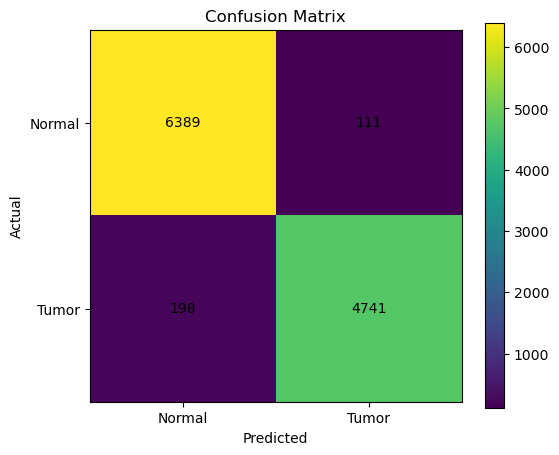

In [29]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Normal", "Tumor"])
plt.yticks([0,1], ["Normal", "Tumor"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## SECTION 22: FINAL SEGMENTATION EVALUATION

In [30]:
@torch.no_grad()
def evaluate_segmentation(model, loader):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_pix = 0.0

    for imgs, msks in loader:
        imgs = imgs.to(DEVICE)
        msks = msks.to(DEVICE)

        preds = model(imgs)
        loss = seg_criterion(preds, msks)

        total_loss += loss.item()
        total_dice += dice_coefficient(preds, msks).item()
        total_iou += iou_score(preds, msks).item()
        total_pix += pixel_accuracy(preds, msks).item()

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    avg_iou = total_iou / len(loader)
    avg_pix = total_pix / len(loader)

    print("FINAL SEGMENTATION SUMMARY")
    print(f"Loss     : {avg_loss:.4f}")
    print(f"Dice     : {avg_dice:.4f}")
    print(f"IoU      : {avg_iou:.4f}")
    print(f"Pixel Acc: {avg_pix:.4f}")

    return {
        "loss": avg_loss,
        "dice": avg_dice,
        "iou": avg_iou,
        "pixel_acc": avg_pix
    }

seg_metrics = evaluate_segmentation(seg_model, seg_val_loader)

FINAL SEGMENTATION SUMMARY
Loss     : 0.2088
Dice     : 0.7959
IoU      : 0.7300
Pixel Acc: 0.9982


## SECTION 23: COMBINED EXPERIMENT SUMMARY

In [31]:
print("FINAL PROJECT SUMMARY")
print("-" * 40)
print("Classification")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nSegmentation")
print(f"Loss      : {seg_metrics['loss']:.4f}")
print(f"Dice      : {seg_metrics['dice']:.4f}")
print(f"IoU       : {seg_metrics['iou']:.4f}")
print(f"Pixel Acc : {seg_metrics['pixel_acc']:.4f}")

FINAL PROJECT SUMMARY
----------------------------------------
Classification
Accuracy  : 0.9730
Precision : 0.9771
Recall    : 0.9599
F1 Score  : 0.9684

Segmentation
Loss      : 0.2088
Dice      : 0.7959
IoU       : 0.7300
Pixel Acc : 0.9982


## SECTION 24: SAVE FINAL METRICS

In [32]:
final_results = pd.DataFrame([
    {
        "classifier_accuracy": acc,
        "classifier_precision": prec,
        "classifier_recall": rec,
        "classifier_f1": f1,
        "segmentation_loss": seg_metrics["loss"],
        "segmentation_dice": seg_metrics["dice"],
        "segmentation_iou": seg_metrics["iou"],
        "segmentation_pixel_acc": seg_metrics["pixel_acc"]
    }
])

final_results.to_csv(os.path.join(SAVE_DIR, "final_results_summary.csv"), index=False)

print("Final results summary saved")
print(final_results)

Final results summary saved
   classifier_accuracy  classifier_precision  classifier_recall  \
0             0.972987              0.977123           0.959911   

   classifier_f1  segmentation_loss  segmentation_dice  segmentation_iou  \
0        0.96844           0.208798            0.79588          0.730035   

   segmentation_pixel_acc  
0                0.998236  


## SECTION 25: CLASSIFICATION ROC CURVE

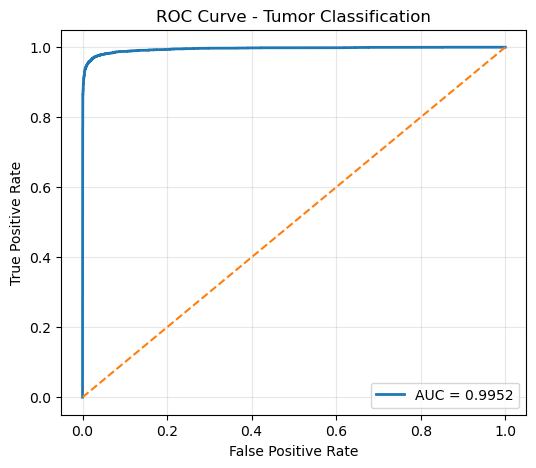

In [33]:
from sklearn.metrics import roc_curve, auc

all_probs = []
all_labels = []

cls_model.eval()

with torch.no_grad():
    for imgs, lbls in cls_val_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        out = cls_model(imgs)
        probs = torch.softmax(out, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tumor Classification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## SECTION 26: SAVE RANDOM INFERENCE VISUALIZATIONS

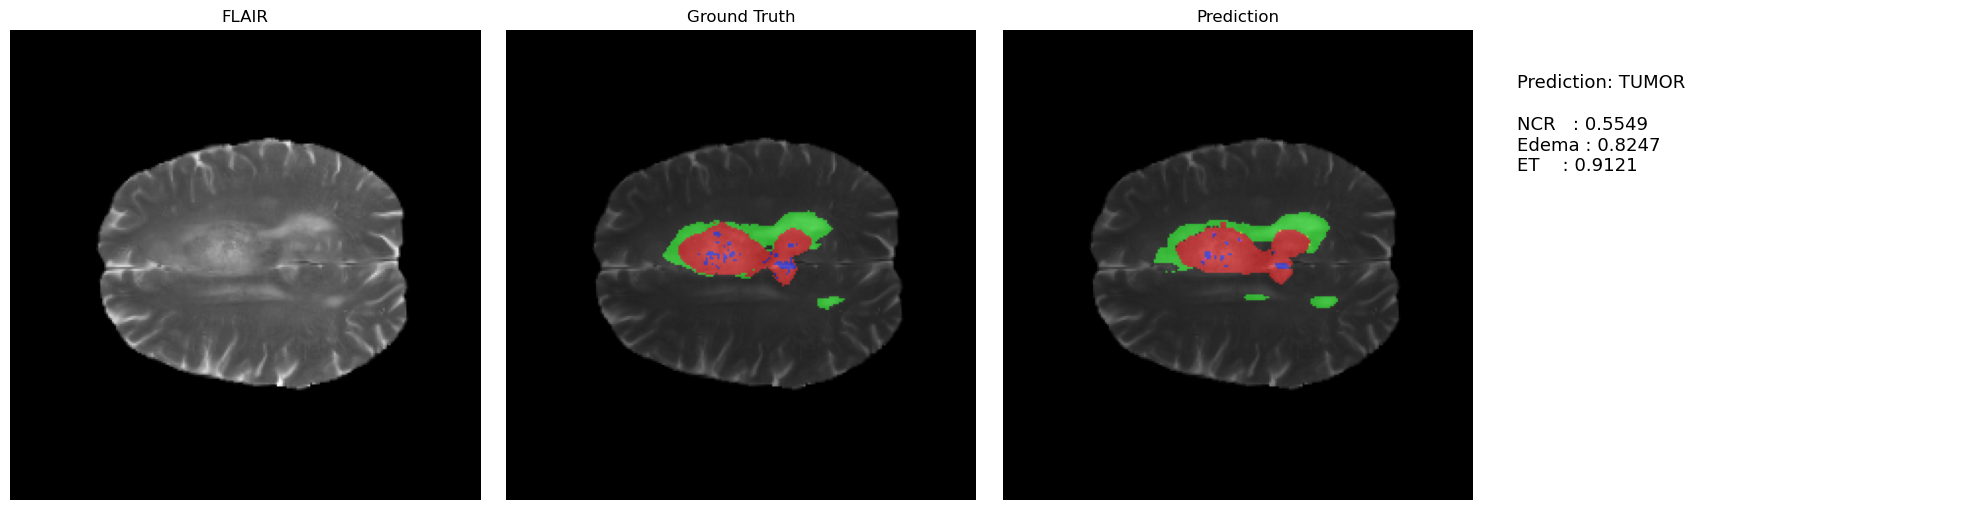

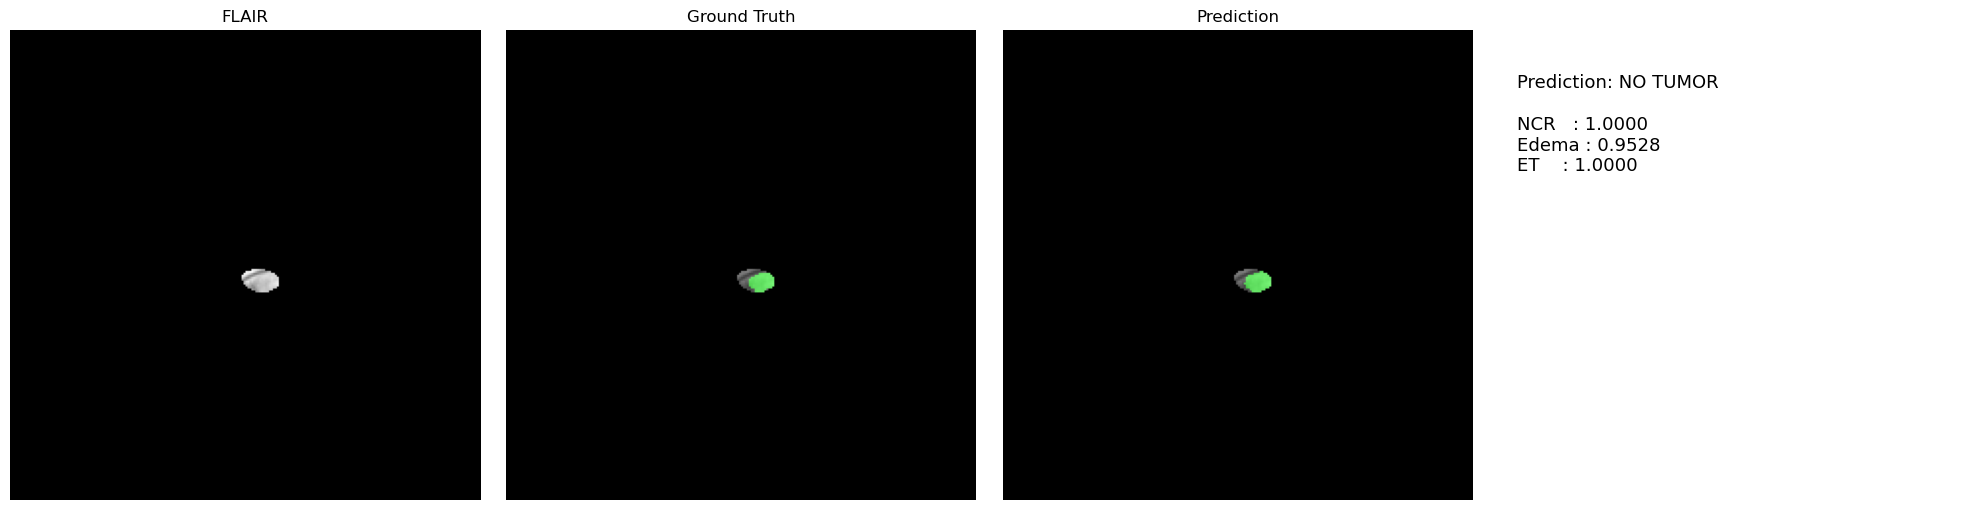

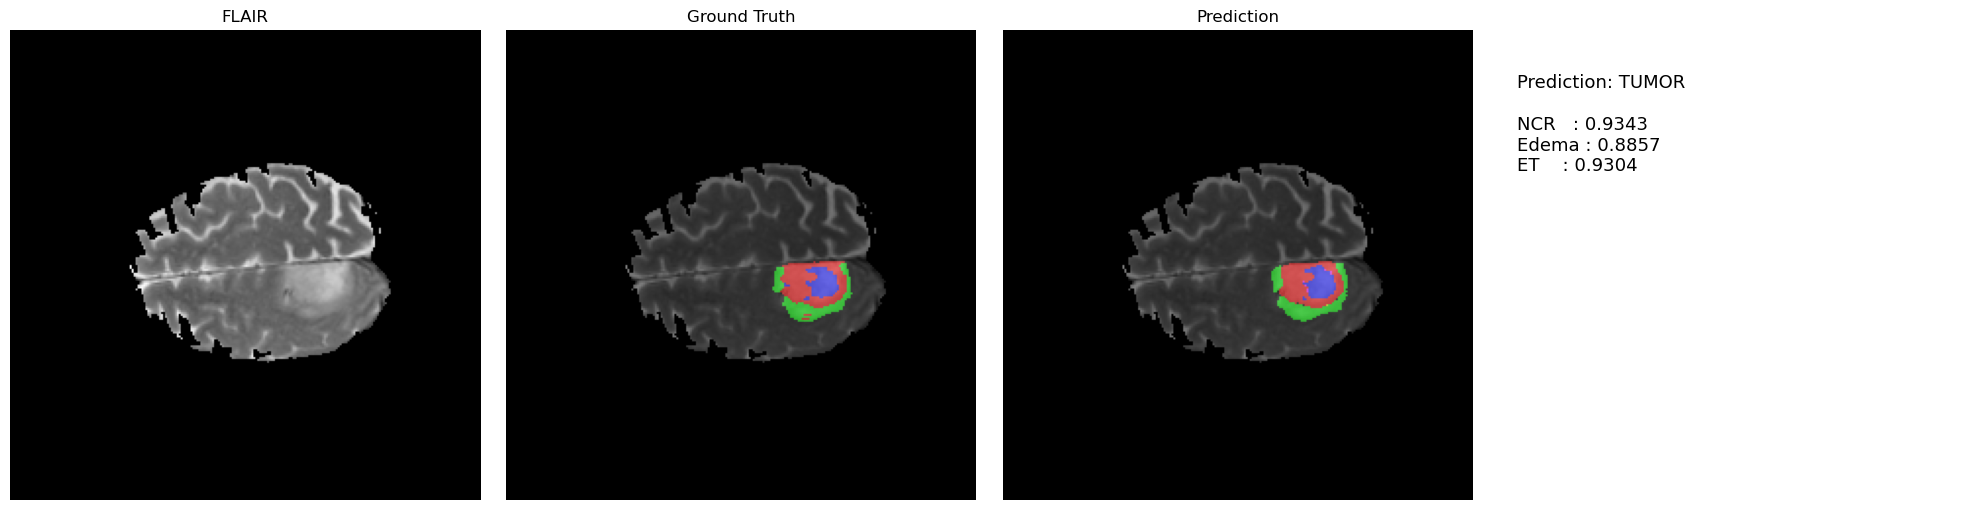

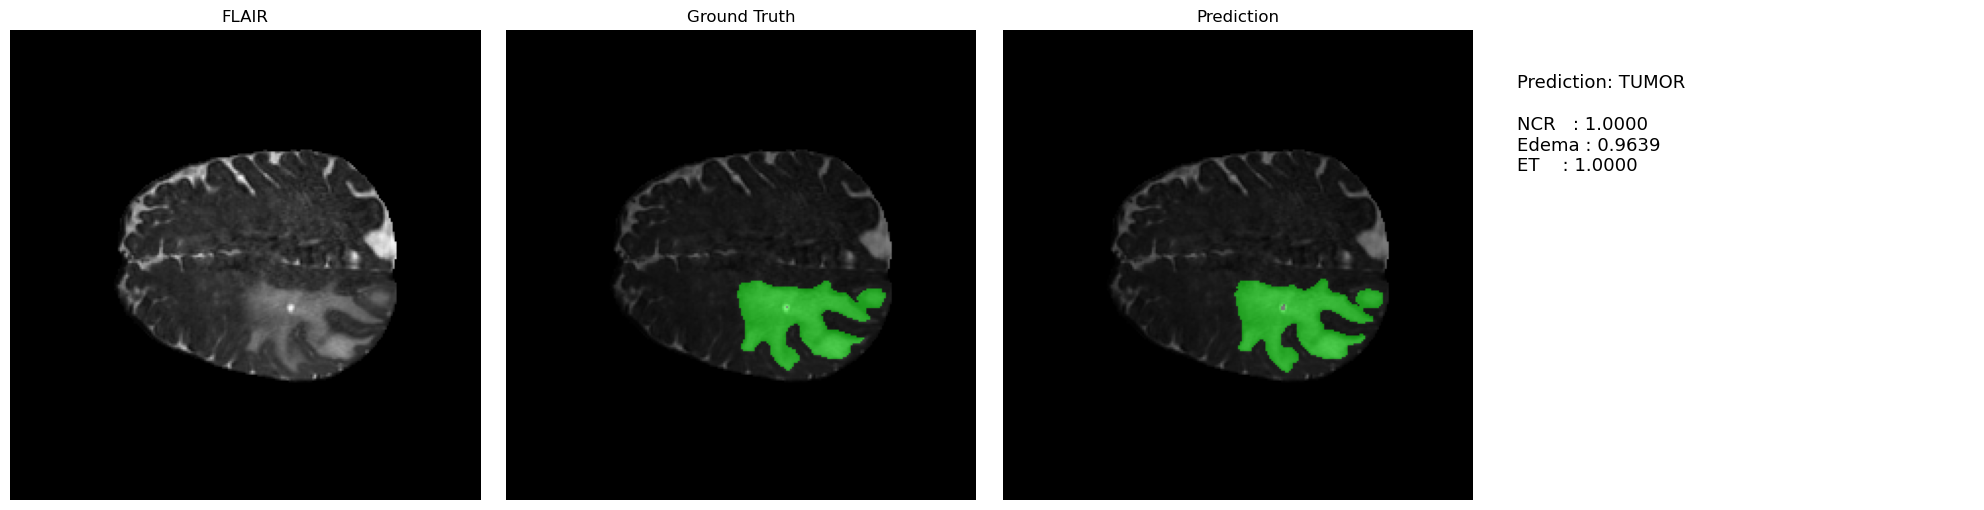

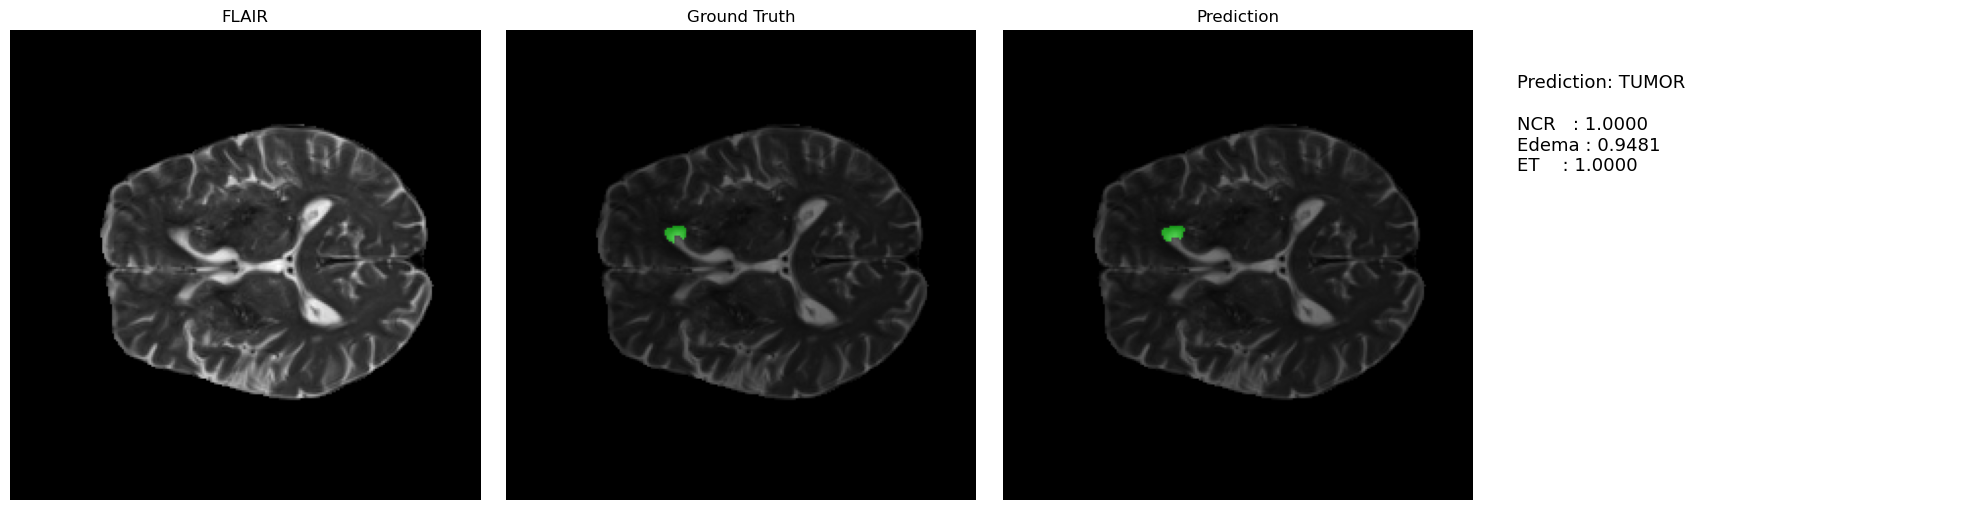

In [34]:
OUTPUT_DIR = os.path.join(SAVE_DIR, "inference_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_random_inference_results(cls_model, seg_model, meta, data_dir, n_samples=5):
    cls_model.eval()
    seg_model.eval()

    tumor_samples = meta[meta['target'] == 1].sample(n_samples, random_state=42)

    for idx, (_, row) in enumerate(tumor_samples.iterrows(), 1):
        fname = f"volume_{int(row['volume'])}_slice_{int(row['slice'])}.h5"
        fpath = os.path.join(data_dir, fname)

        with h5py.File(fpath, 'r') as f:
            image = f['image'][()].astype(np.float32)
            mask = f['mask'][()].astype(np.float32)

        img_norm = image.copy()
        for c in range(4):
            mn = img_norm[:, :, c].min()
            mx = img_norm[:, :, c].max()
            if mx > mn:
                img_norm[:, :, c] = (img_norm[:, :, c] - mn) / (mx - mn)

        tensor = (
            torch.tensor(img_norm)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .float()
            .to(DEVICE)
        )

        with torch.no_grad():
            cls_out = cls_model(tensor)
            pred_cls = cls_out.argmax(1).item()

            seg_out = seg_model(tensor)
            seg_out = torch.sigmoid(seg_out).squeeze(0).cpu().numpy()

        scores = region_dice(seg_out, mask)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        axes[0].imshow(img_norm[:, :, 3], cmap='gray')
        axes[0].set_title("FLAIR")
        axes[0].axis('off')

        gt_overlay = np.zeros((240, 240, 3))
        gt_overlay[:, :, 0] = mask[:, :, 2]
        gt_overlay[:, :, 1] = mask[:, :, 1]
        gt_overlay[:, :, 2] = mask[:, :, 0]

        axes[1].imshow(img_norm[:, :, 3], cmap='gray')
        axes[1].imshow(gt_overlay, alpha=0.5)
        axes[1].set_title("Ground Truth")
        axes[1].axis('off')

        pred_overlay = np.zeros((240, 240, 3))
        pred_overlay[:, :, 0] = (seg_out[2] > 0.5)
        pred_overlay[:, :, 1] = (seg_out[1] > 0.5)
        pred_overlay[:, :, 2] = (seg_out[0] > 0.5)

        axes[2].imshow(img_norm[:, :, 3], cmap='gray')
        axes[2].imshow(pred_overlay, alpha=0.5)
        axes[2].set_title("Prediction")
        axes[2].axis('off')

        axes[3].text(
            0.05, 0.7,
            f"Prediction: {'TUMOR' if pred_cls == 1 else 'NO TUMOR'}\n\n"
            f"NCR   : {scores[0]:.4f}\n"
            f"Edema : {scores[1]:.4f}\n"
            f"ET    : {scores[2]:.4f}",
            fontsize=13
        )
        axes[3].axis('off')

        plt.tight_layout()

        save_path = os.path.join(
            OUTPUT_DIR,
            f"sample_{idx}_volume_{int(row['volume'])}_slice_{int(row['slice'])}.png"
        )
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()

save_random_inference_results(
    cls_model,
    seg_model,
    meta,
    DATA_DIR,
    n_samples=5
)

## SECTION 27: VALIDATION SAMPLE GALLERY

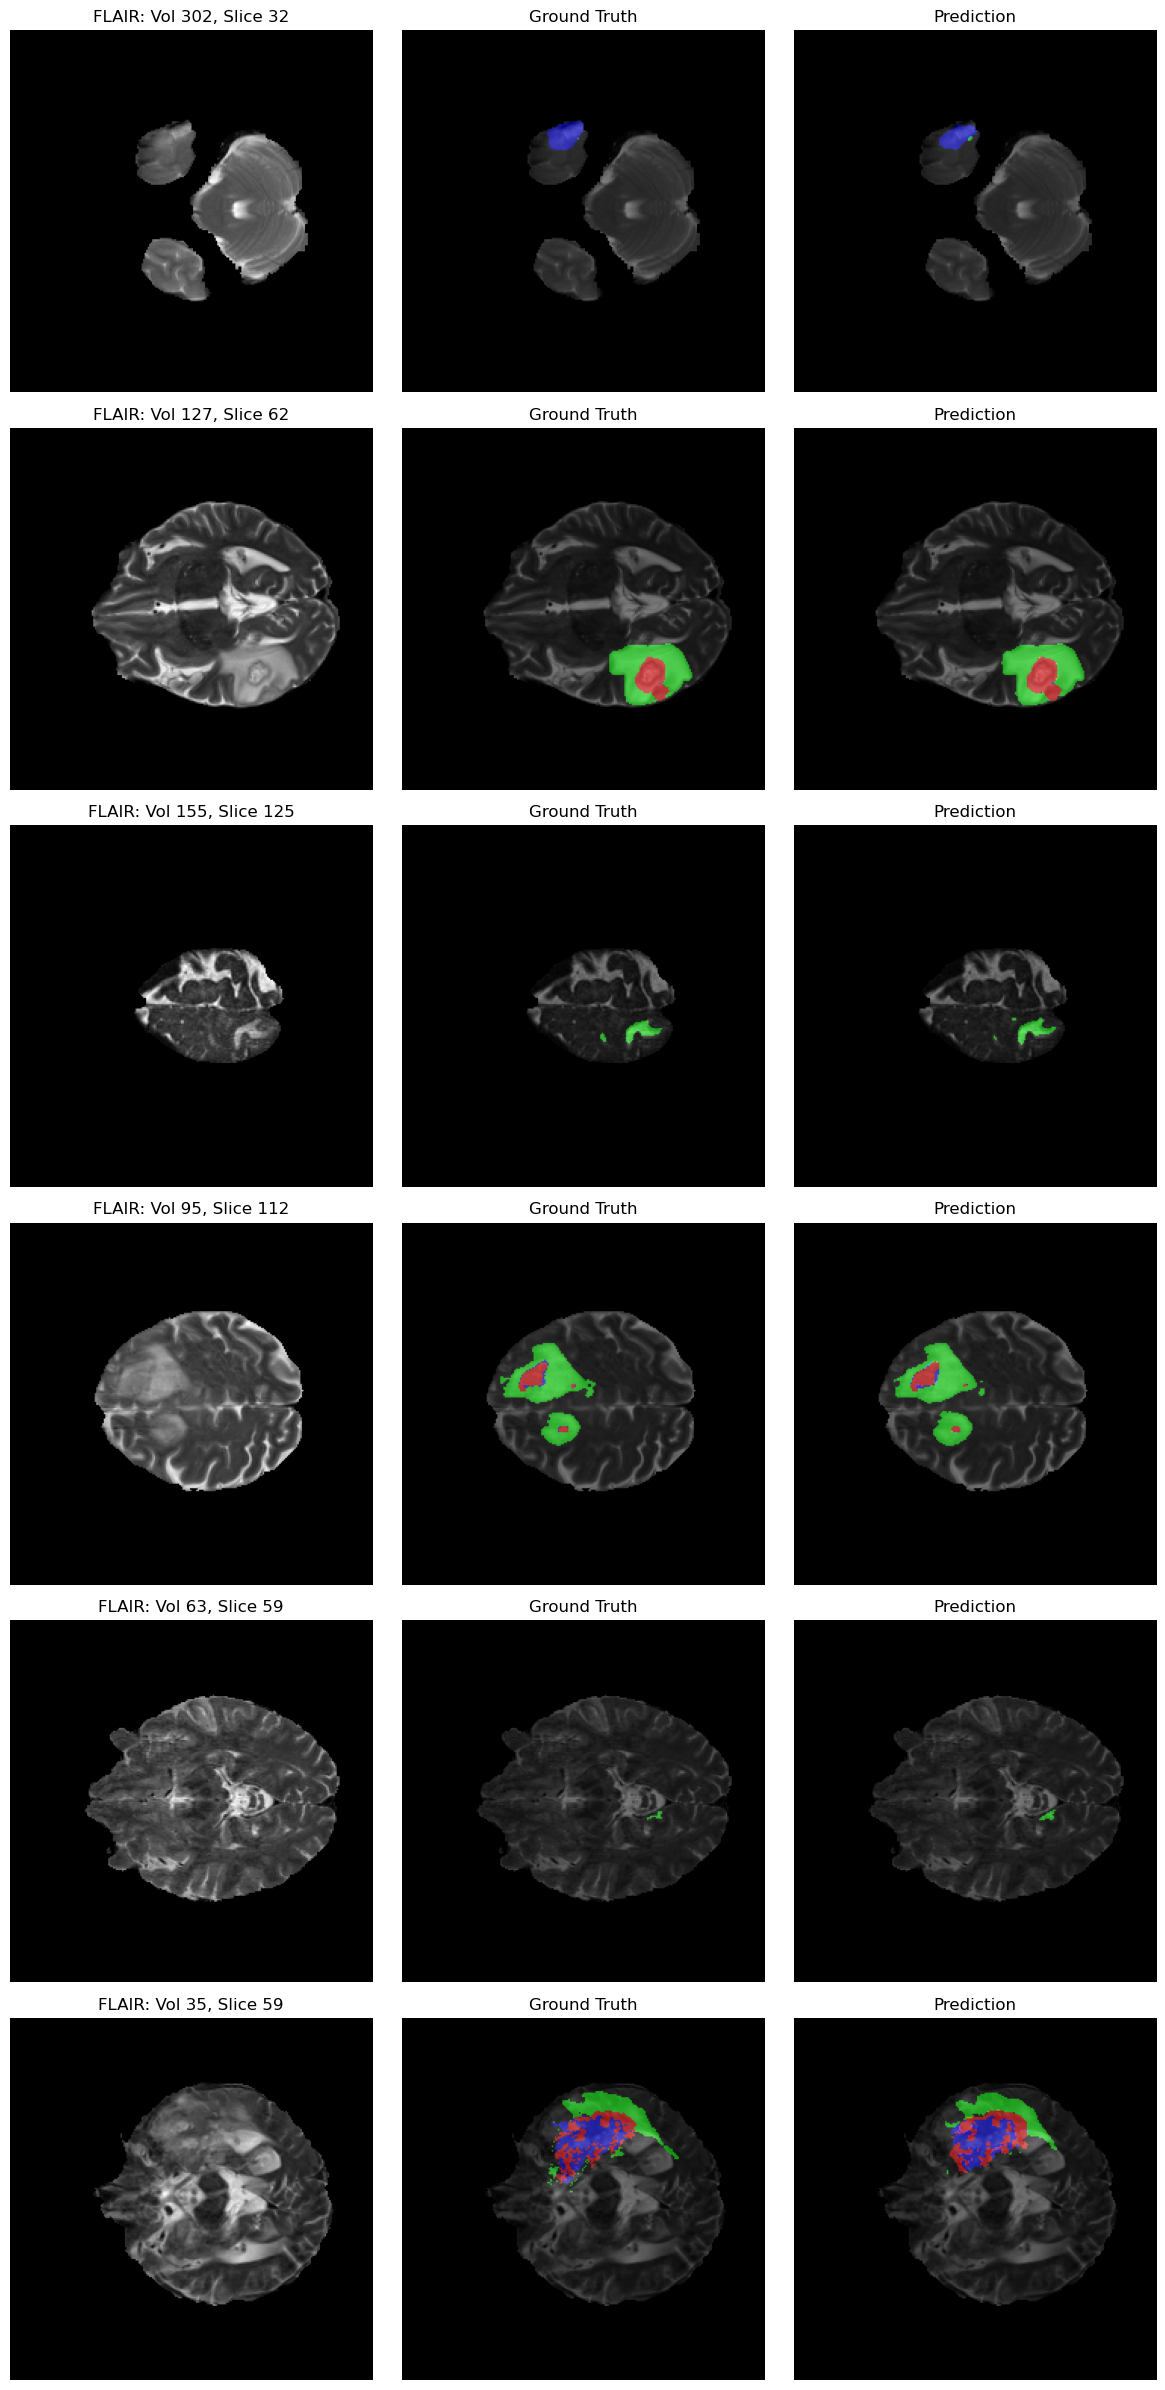

In [35]:
def show_validation_gallery(seg_model, meta, data_dir, n_samples=6):
    seg_model.eval()

    samples = meta[meta['target'] == 1].sample(n_samples, random_state=7).reset_index(drop=True)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))

    for i, row in samples.iterrows():
        fname = f"volume_{int(row['volume'])}_slice_{int(row['slice'])}.h5"
        fpath = os.path.join(data_dir, fname)

        with h5py.File(fpath, 'r') as f:
            image = f['image'][()].astype(np.float32)
            mask = f['mask'][()].astype(np.float32)

        img_norm = image.copy()
        for c in range(4):
            mn = img_norm[:, :, c].min()
            mx = img_norm[:, :, c].max()
            if mx > mn:
                img_norm[:, :, c] = (img_norm[:, :, c] - mn) / (mx - mn)

        tensor = (
            torch.tensor(img_norm)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .float()
            .to(DEVICE)
        )

        with torch.no_grad():
            pred = seg_model(tensor)
            pred = torch.sigmoid(pred).squeeze(0).cpu().numpy()

        gt_overlay = np.zeros((240, 240, 3))
        gt_overlay[:, :, 0] = mask[:, :, 2]
        gt_overlay[:, :, 1] = mask[:, :, 1]
        gt_overlay[:, :, 2] = mask[:, :, 0]

        pred_overlay = np.zeros((240, 240, 3))
        pred_overlay[:, :, 0] = (pred[2] > 0.5)
        pred_overlay[:, :, 1] = (pred[1] > 0.5)
        pred_overlay[:, :, 2] = (pred[0] > 0.5)

        axes[i, 0].imshow(img_norm[:, :, 3], cmap='gray')
        axes[i, 0].set_title(f"FLAIR: Vol {int(row['volume'])}, Slice {int(row['slice'])}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_norm[:, :, 3], cmap='gray')
        axes[i, 1].imshow(gt_overlay, alpha=0.5)
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img_norm[:, :, 3], cmap='gray')
        axes[i, 2].imshow(pred_overlay, alpha=0.5)
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

show_validation_gallery(seg_model, meta, DATA_DIR, n_samples=6)